### SVMs y optimización de hiperparámetros

En este notebook trabajaremos con un dataset simulado de eventos del experimento ATLAS. Cada fila representa un evento de colisión protón–protón, y cada columna corresponde a una variable reconstruida a partir de los objetos físicos detectados en el evento: jets, leptones, energía faltante, etc.

El objetivo es distinguir entre dos tipos de eventos:

- **`ttbar`**: producción de un par top–antitop. Es un proceso mucho más frecuente.
- **`4top`**: producción de cuatro quarks top. Es un proceso mucho más raro y corresponde a nuestra clase positiva.


Basado en Machine learning for physics and Astronomy, Viviana Acquaviva (2023)





In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import rc
from sklearn.svm import SVC, LinearSVC # Nuevo algoritmo!
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_predict, cross_validate
from sklearn.model_selection import KFold, StratifiedKFold
from sklearn import metrics
from sklearn.model_selection import GridSearchCV # Nuevo! Para explorar los hiperparámetros del modelo

In [2]:
pd.set_option('display.max_columns', 500)
pd.set_option('display.max_rows', 500)
pd.set_option('display.max_colwidth', 100)
rc('text', usetex=False)

Leemos las características y las etiquetas  

In [3]:
features = pd.read_csv('ParticleID_features.csv', index_col='ID')

In [4]:
features.head(10)

,MET,METphi,Type_1,P1,P2,P3,P4,Type_2,P5,P6,P7,P8,Type_3,P9,P10,P11,P12,Type_4,P13,P14,P15,P16,Type_5,P17,P18,P19,P20,Type_6,P21,P22,P23,P24,Type_7,P25,P26,P27,P28,Type_8,P29,P30,P31,P32,Type_9,P33,P34,P35,P36,Type_10,P37,P38,P39,P40,Type_11,P41,P42,P43,P44,Type_12,P45,P46,P47,P48,Type_13,P49,P50,P51,P52
ID,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
0,62803.50,-1.810010,j,137571.0,128444.0,-0.345744,-0.307112,j,174209.0,127932.0,0.826569,2.332000,b,86788.9,84554.9,-0.180795,2.187970,j,140289.0,76955.8,-1.199330,-1.302800,m+,85230.6,70102.4,-0.645689,-1.659540,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,57594.20,-0.509253,j,161529.0,80458.3,-1.318010,1.402050,j,291490.0,68462.9,-2.126740,-2.582310,e-,44270.1,35139.6,-0.706120,-0.371392,e+,72883.9,26902.2,-1.653860,-3.129630,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,82313.30,1.686840,b,167130.0,113078.0,0.937258,-2.068680,j,102423.0,54922.3,1.226850,0.646589,j,60768.9,36244.3,1.102890,-1.434480,j,77714.0,27801.5,1.684610,1.389690,j,26840.0,24469.3,-0.388937,-1.647260,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,30610.80,2.617120,j,112267.0,61383.9,-1.211050,-1.457800,b,40647.8,39472.0,-0.024646,-2.222800,j,201589.0,32978.6,-2.496040,1.137810,j,90096.7,26964.5,1.871320,0.817631,j,28235.4,25887.9,-0.411528,2.024290,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,45153.10,-2.241350,j,178174.0,100164.0,1.166880,-0.018721,j,92351.3,69762.1,0.774114,2.568740,j,61625.2,50086.7,0.652572,-3.012800,j,104193.0,31151.0,1.876410,0.865381,j,746585.0,26219.3,4.041820,-0.874169,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,43803.10,0.572184,b,146274.0,111016.0,-0.776311,1.083980,j,1036150.0,109475.0,-2.937790,-1.518380,j,259026.0,71613.8,-1.955480,-1.726540,j,137198.0,59925.9,-1.469500,2.189410,j,95419.6,55847.5,1.123310,0.846395,j,451389.0,53178.9,-2.827840,-2.47964,j,51436.4,50713.2,0.056029,2.258540,j,152293.0,48842.5,-1.80056,-0.704609,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,28100.40,-0.593429,j,458244.0,391557.0,-0.546723,0.013275,b,425427.0,328566.0,-0.728581,-2.411570,j,126694.0,116820.0,-0.350992,2.208790,j,112382.0,111318.0,0.073453,3.030960,j,3039490.0,65143.9,4.535880,1.516880,j,86235.2,65037.1,0.780704,1.50869,b,62675.6,61535.7,0.099510,0.466516,j,82070.6,45537.5,-1.18149,-3.047850,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,166458.00,0.473635,j,848058.0,273398.0,-1.794510,2.763560,j,267149.0,242308.0,-0.425923,-1.534860,b,461064.0,159944.0,-1.719880,1.094360,j,75909.0,73858.8,-0.235076,-0.330519,b,201351.0,53338.2,-2.002180,-2.376840,b,38794.0,37225.5,0.187429,-2.78635,b,40323.4,36915.1,0.411490,1.844490,j,195049.0,28645.2,-2.60528,-1.434260,j,210687.0,26560.5,2.75992,0.315873,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,4664.13,-1.828120,j,477219.0,331550.0,-0.899484,0.698675,b,696365.0,246682.0,-1.697140,-2.285070,j,987005.0,62516.5,-3.451230,-2.207720,j,51561.9,36406.3,-0.881624,-2.923760,j,85262.1,35203.6,-1.527390,2.071480,j,202166.0,26361.8,-2.725680,-2.21350,j,56071.6,25934.6,-1.403180,1.130990,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Cada fila del dataset corresponde a un evento de colisión protón-protón.
Para cada evento se conoce:
- Energía faltante:
  - `MET`: energía transversa faltante (*missing transverse energy*)
  - `METphi`: ángulo azimutal asociado a la dirección de la energía faltante
- Información de cada partícula reconstruida: Para cada partícula se registra:
    - Tipo de partícula, que puede ser: electrón, positrón, fotón, jet, b-jet, muón con carga positiva, muón con carga negativa
    - 4-vector, que describe la cinemática de la partícula. En este dataset, el 4-vector incluye: energía, momento transversal, pseudorapidez $\eta$ y ángulo azimutal $\phi$


In [5]:
features.shape

(5000, 67)

In [6]:
y = np.genfromtxt('ParticleID_labels.txt', dtype = str)

In [7]:
y

array(['ttbar', 'ttbar', 'ttbar', ..., 'ttbar', '4top', 'ttbar'],
      dtype='<U5')

### Objetivo del problema

Queremos entrenar un clasificador que distinga entre dos tipos de eventos:

- `ttbar`: producción de un par top-antitop.
- `4top`: producción de cuatro quarks top.

#### Necesitamos transformar las dos categorías de targets desde un string a un valor numérico, como 0/1. Podemos usar la función [`LabelEncoder`](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.LabelEncoder.html) de sklearn

In [8]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder() #cambia las categorías a 1...N

In [9]:
y

array(['ttbar', 'ttbar', 'ttbar', ..., 'ttbar', '4top', 'ttbar'],
      dtype='<U5')

In [10]:
y = le.fit_transform(y)

In [11]:
le.classes_

array(['4top', 'ttbar'], dtype='<U5')

`LabelEncoder` asigna números a las clases en el orden definido por `le.classes_`.  
Como queremos que `4top` sea la clase positiva, revisamos la codificación y, si es necesario, invertimos las etiquetas.

In [12]:
target = np.abs(y - 1)

In [13]:
target # Ahora sí

array([0, 0, 0, ..., 0, 1, 0])

In [14]:
y.shape

(5000,)

#### Echemos un vistazo a las características

In [15]:
features.describe() #Esto excluye a las columnas con datos no-numéricos

,MET,METphi,P1,P2,P3,P4,P5,P6,P7,P8,P9,P10,P11,P12,P13,P14,P15,P16,P17,P18,P19,P20,P21,P22,P23,P24,P25,P26,P27,P28,P29,P30,P31,P32,P33,P34,P35,P36,P37,P38,P39,P40,P41,P42,P43,P44,P45,P46,P47,P48,P49,P50,P51,P52
count,5000.000000,5000.000000,5.000000e+03,5.000000e+03,5000.000000,5000.000000,4.997000e+03,4.997000e+03,4997.000000,4997.000000,4.950000e+03,4950.000000,4950.000000,4950.000000,4.717000e+03,4717.000000,4717.000000,4717.000000,4.002000e+03,4002.000000,4002.000000,4002.000000,2.871000e+03,2871.00000,2871.000000,2871.000000,1.889000e+03,1889.000000,1889.000000,1889.000000,1.186000e+03,1186.000000,1186.000000,1186.000000,7.290000e+02,729.000000,729.000000,729.000000,4.420000e+02,442.000000,442.000000,442.000000,2.610000e+02,261.000000,261.000000,261.000000,1.270000e+02,127.000000,127.000000,127.000000,5.600000e+01,56.000000,56.000000,56.000000
mean,64071.074332,-0.028916,3.301357e+05,1.540486e+05,-0.039812,-0.003049,2.527799e+05,1.080302e+05,-0.029936,0.007327,2.117980e+05,74863.343131,-0.025104,0.011845,1.805997e+05,57289.049481,0.010723,0.045266,1.780366e+05,48798.018516,0.015167,-0.031312,1.705620e+05,44042.67015,-0.022948,0.014522,1.628825e+05,41151.069666,0.002228,0.006738,1.581409e+05,40250.387015,0.072349,-0.035907,1.596814e+05,40139.289849,0.061654,-0.045868,1.574039e+05,39703.038235,0.118543,0.024249,1.561160e+05,38173.716092,0.029455,0.026422,1.631051e+05,34876.849606,0.206978,-0.001085,1.456600e+05,36151.183929,-0.000879,0.219260
std,60525.122480,1.819257,3.068202e+05,1.149469e+05,1.361762,1.814855,2.638580e+05,8.136261e+04,1.439105,1.828832,2.510361e+05,46309.512365,1.577316,1.802715,2.383403e+05,32013.857623,1.634072,1.812078,2.577958e+05,26252.978520,1.744489,1.784248,2.381745e+05,23510.65367,1.806611,1.811101,2.269341e+05,20988.953157,1.815312,1.771888,2.118782e+05,26556.025657,1.836492,1.796932,2.308620e+05,30074.756789,1.842798,1.788596,2.165489e+05,30502.312276,1.872084,1.826435,2.319016e+05,29324.658352,1.884750,1.753017,2.248603e+05,20433.767238,1.998859,1.949004,1.943657e+05,25861.883410,1.941707,1.910400
min,290.756000,-3.141010,3.857940e+04,2.825400e+04,-4.110220,-3.140710,1.087540e+04,1.080000e+04,-4.668790,-3.140530,1.221050e+04,10639.800000,-4.520250,-3.141480,1.169190e+04,10818.000000,-4.616550,-3.136130,1.110310e+04,10287.000000,-4.778980,-3.139040,1.070330e+04,10066.90000,-4.930230,-3.140380,1.197700e+04,11260.200000,-4.758150,-3.135630,1.380860e+04,10973.300000,-4.606330,-3.132610,1.119760e+04,10067.900000,-4.814380,-3.136380,1.615530e+04,10183.700000,-4.803880,-3.135910,2.004750e+04,14800.200000,-4.400470,-3.130690,1.780380e+04,12987.900000,-4.447660,-3.139820,2.512510e+04,14836.000000,-4.448760,-2.990730
25%,24352.375000,-1.619905,1.369522e+05,8.883690e+04,-1.035570,-1.574213,1.007510e+05,6.321840e+04,-1.060500,-1.602460,7.636905e+04,46549.475000,-1.125620,-1.547418,5.999090e+04,36097.700000,-1.121240,-1.518030,5.278370e+04,30891.650000,-1.198468,-1.550615,5.007050e+04,28453.95000,-1.250050,-1.586675,4.695560e+04,27963.500000,-1.231420,-1.475380,4.535515e+04,27140.550000,-1.243962,-1.626688,4.387110e+04,26825.000000,-1.226980,-1.513330,4.410735e+04,26589.250000,-1.223240,-1.422415,4.092160e+04,25298.300000,-1.413650,-1.270700,4.365005e+04,24742.500000,-1.259230,-1.817600,4.112588e+04,24974.125000,-1.243362,-1.490900
50%,46814.400000,-0.055612,2.263525e+05,1.182015e+05,-0.038731,-0.009037,1.659740e+05,8.584360e+04,-0.057428,0.015111,1.288565e+05,62498.400000,-0.040648,0.034238,9.922610e+04,48949.200000,-0.035512,0.060279,9.206885e+04,41054.850000,0.054393,-0.079641,8.593460e+04,37378.30000,-0.046667,0.040528,7.975460e+04,34681.700000,0.025305,0.046141,8.315485e+04,33683.550000,0.156083,-0.015617,7.894980e+04,33328.000000,0.072709,-0.052590,7.609735e+04,30942.700000,0.035675,0.090282,7.568430e+04,29479.700000,-0.088908,-0.041002,8.050910e+04,28262.800000,0.120301,-0.232455,9.553645e+04,27353.550000,-0.121213,0.128103
75%,83032.350000,1.537323,4.077158e+05,1.771265e+05,0.943598,1.542370,2.9999

In [17]:
features.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5000 entries, 0 to 4999
Data columns (total 67 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   MET      5000 non-null   float64
 1   METphi   5000 non-null   float64
 2   Type_1   5000 non-null   object 
 3   P1       5000 non-null   float64
 4   P2       5000 non-null   float64
 5   P3       5000 non-null   float64
 6   P4       5000 non-null   float64
 7   Type_2   4997 non-null   object 
 8   P5       4997 non-null   float64
 9   P6       4997 non-null   float64
 10  P7       4997 non-null   float64
 11  P8       4997 non-null   float64
 12  Type_3   4950 non-null   object 
 13  P9       4950 non-null   float64
 14  P10      4950 non-null   float64
 15  P11      4950 non-null   float64
 16  P12      4950 non-null   float64
 17  Type_4   4717 non-null   object 
 18  P13      4717 non-null   float64
 19  P14      4717 non-null   float64
 20  P15      4717 non-null   float64
 21  P16      4717 non-n

### Importante:

En este dataset, los NaN aparecen porque no todos los eventos tienen la misma cantidad de partículas reconstruidas.  
Al reemplazar por 0, estamos codificando implícitamente la ausencia de una partícula.

Esto puede ser razonable, pero también puede introducir una señal artificial: el modelo podría aprender no solo de las variables físicas, sino también de cuántas partículas fueron registradas.


**¿Qué podemos hacer?**

#### Opción 1: Sólo considerar las primeras 16 columnas (4 primeros productos)

De esta forma, reducimos los problemas de manipulación o de imputación de datos faltantes.


Tenemos un trade-off entre tener más features, pero si tenemos más, tendremos muchos datos faltantes que tendremos que reemplazar (imputing), o mantenemos menos features, pero el problema es más simple

In [22]:
#limitamos los features
features_lim = features[['MET', 'METphi', 'P1', 'P2', 'P3', 'P4', 'P5', 'P6', 'P7', 'P8', 'P9', 'P10', 'P11',
       'P12',  'P13', 'P14', 'P15', 'P16']]

In [23]:
features_lim.head()

,MET,METphi,P1,P2,P3,P4,P5,P6,P7,P8,P9,P10,P11,P12,P13,P14,P15,P16
ID,,,,,,,,,,,,,,,,,,
0,62803.5,-1.810010,137571.0,128444.0,-0.345744,-0.307112,174209.0,127932.0,0.826569,2.332000,86788.9,84554.9,-0.180795,2.187970,140289.0,76955.8,-1.19933,-1.302800
1,57594.2,-0.509253,161529.0,80458.3,-1.318010,1.402050,291490.0,68462.9,-2.126740,-2.582310,44270.1,35139.6,-0.706120,-0.371392,72883.9,26902.2,-1.65386,-3.129630
2,82313.3,1.686840,167130.0,113078.0,0.937258,-2.068680,102423.0,54922.3,1.226850,0.646589,60768.9,36244.3,1.102890,-1.434480,77714.0,27801.5,1.68461,1.389690
3,30610.8,2.617120,112267.0,61383.9,-1.211050,-1.457800,40647.8,39472.0,-0.024646,-2.222800,201589.0,32978.6,-2.496040,1.137810,90096.7,26964.5,1.87132,0.817631
4,45153.1,-2.241350,178174.0,100164.0,1.166880,-0.018721,92351.3,69762.1,0.774114,2.568740,61625.2,50086.7,0.652572,-3.012800,104193.0,31151.0,1.87641,0.865381


In [24]:
features_lim.describe()

,MET,METphi,P1,P2,P3,P4,P5,P6,P7,P8,P9,P10,P11,P12,P13,P14,P15,P16
count,5000.000000,5000.000000,5.000000e+03,5.000000e+03,5000.000000,5000.000000,4.997000e+03,4.997000e+03,4997.000000,4997.000000,4.950000e+03,4950.000000,4950.000000,4950.000000,4.717000e+03,4717.000000,4717.000000,4717.000000
mean,64071.074332,-0.028916,3.301357e+05,1.540486e+05,-0.039812,-0.003049,2.527799e+05,1.080302e+05,-0.029936,0.007327,2.117980e+05,74863.343131,-0.025104,0.011845,1.805997e+05,57289.049481,0.010723,0.045266
std,60525.122480,1.819257,3.068202e+05,1.149469e+05,1.361762,1.814855,2.638580e+05,8.136261e+04,1.439105,1.828832,2.510361e+05,46309.512365,1.577316,1.802715,2.383403e+05,32013.857623,1.634072,1.812078
min,290.756000,-3.141010,3.857940e+04,2.825400e+04,-4.110220,-3.140710,1.087540e+04,1.080000e+04,-4.668790,-3.140530,1.221050e+04,10639.800000,-4.520250,-3.141480,1.169190e+04,10818.000000,-4.616550,-3.136130
25%,24352.375000,-1.619905,1.369522e+05,8.883690e+04,-1.035570,-1.574213,1.007510e+05,6.321840e+04,-1.060500,-1.602460,7.636905e+04,46549.475000,-1.125620,-1.547418,5.999090e+04,36097.700000,-1.121240,-1.518030
50%,46814.400000,-0.055612,2.263525e+05,1.182015e+05,-0.038731,-0.009037,1.659740e+05,8.584360e+04,-0.057428,0.015111,1.288565e+05,62498.400000,-0.040648,0.034238,9.922610e+04,48949.200000,-0.035512,0.060279
75%,83032.350000,1.537323,4.077158e+05,1.771265e+05,0.943598,1.542370,2.999950e+05,1.238700e+05,1.028340,1.605210,2.421225e+05,89587.500000,1.066302,1.570887,1.914340e+05,68782.100000,1.159480,1.612220
max,692674.000000,3.141130,3.186360e+06,1.276710e+06,4.141410,3.138540,3.587700e+06,1.146330e+06,4.559150,3.139200,2.800410e+06,788338.000000,4.798090,3.139020,2.503590e+06,481884.000000,4.730480,3.139660


Todavía tenemos datos faltantes (valores NaN). Los reemplazaremos con 0

In [25]:
features_lim = features_lim.fillna(0) #Llena todo lo que es NaN con 0

#### ¿Qué opina de esta estrategia?



Esta estrategia no es buena ya que al eliminar datos, o reemplazarlos, se esta perdiendo física. La cantidad de particuals creadas con la colisión es parte importante de la física detras de cada colisión, por lo que no es correcto eliminar datos.

#### Si revisamos nuevamente con `describe`

In [26]:
features_lim.describe()

,MET,METphi,P1,P2,P3,P4,P5,P6,P7,P8,P9,P10,P11,P12,P13,P14,P15,P16
count,5000.000000,5000.000000,5.000000e+03,5.000000e+03,5000.000000,5000.000000,5.000000e+03,5.000000e+03,5000.000000,5000.000000,5.000000e+03,5000.000000,5000.000000,5000.000000,5.000000e+03,5000.000000,5000.000000,5000.000000
mean,64071.074332,-0.028916,3.301357e+05,1.540486e+05,-0.039812,-0.003049,2.526283e+05,1.079653e+05,-0.029918,0.007323,2.096800e+05,74114.709700,-0.024853,0.011727,1.703778e+05,54046.489280,0.010116,0.042704
std,60525.122480,1.819257,3.068202e+05,1.149469e+05,1.361762,1.814855,2.638514e+05,8.138121e+04,1.438673,1.828283,2.506651e+05,46675.655162,1.569410,1.793678,2.352279e+05,33795.723384,1.587146,1.760070
min,290.756000,-3.141010,3.857940e+04,2.825400e+04,-4.110220,-3.140710,0.000000e+00,0.000000e+00,-4.668790,-3.140530,0.000000e+00,0.000000,-4.520250,-3.141480,0.000000e+00,0.000000,-4.616550,-3.136130
25%,24352.375000,-1.619905,1.369522e+05,8.883690e+04,-1.035570,-1.574213,1.007050e+05,6.320943e+04,-1.059270,-1.599617,7.488228e+04,46165.375000,-1.108390,-1.532478,5.480870e+04,33959.400000,-1.050477,-1.424080
50%,46814.400000,-0.055612,2.263525e+05,1.182015e+05,-0.038731,-0.009037,1.658985e+05,8.581595e+04,-0.056810,0.012737,1.277135e+05,62167.100000,-0.023321,0.006687,9.259335e+04,47278.800000,0.000000,0.000000
75%,83032.350000,1.537323,4.077158e+05,1.771265e+05,0.943598,1.542370,2.999058e+05,1.238520e+05,1.028055,1.601880,2.406498e+05,89065.300000,1.048617,1.553310,1.831228e+05,66846.300000,1.085627,1.521765
max,692674.000000,3.141130,3.186360e+06,1.276710e+06,4.141410,3.138540,3.587700e+06,1.146330e+06,4.559150,3.139200,2.800410e+06,788338.000000,4.798090,3.139020,2.503590e+06,481884.000000,4.730480,3.139660


Ahora tenemos tamaños consistentes para poder usarlos como features, PERO hay que estar conciente de los efectos negativos que puede traer nuestra estrategia de imputación

## Benchmark inicial

En este notebook, el benchmark principal es el desempeño de estrategias simples antes de usar un SVM más flexible. Primero comparamos contra un clasificador que siempre predice la clase mayoritaria, ya que el dataset está desbalanceado. Luego, un clasificador aleatorio, es decir, asigna un valor aleatorio a cada clase. Y también usamos un `LinearSVC` con escalamiento como benchmark lineal: una referencia razonable para saber si necesitamos modelos más complejos, como SVM con kernels no lineales.

In [27]:
np.sum(target)/len(target) #distribución

0.1622

84\% en la etiqueta negativa, 16\% en la etiqueta positiva.

Esto significa que un clasificador que pone todo en la clase negativa (lazy classifier) tendrá un 84% de accuracy

Cómo lo haría un clasificador aleatorio que asigna un valor aleatorio a la distribución de clase?

In [28]:
#Numerical solution

acc=0
for i in range(1000): #1000 iteraciones del proceso
    x = np.random.choice(target,5000) #generamos 5000 etiquetas aleatorias
    acc += metrics.accuracy_score(target,x) #calculamos accuracy promedio en las 1000 iteraciones
print(acc/1000)

#Analytic solution
#P(Clase 1)^2 + P(Clase 2)^2 exactitud esperada


print(0.8378*(0.8378) + 0.1622*0.1622)

0.7282447999999997
0.72821768


En conclusión, un clasificador aleatorio tendrá 73% accuracy, un lazy classfier tiene 83% accuracy. Este análisis es útil para tener una expectativa de qué es un "buen resultado" y qué significa una mejora significativa


### Ahora empezaremos con un modelo lineal  model = SVC()

Definimos una estrategia CV, establecemos un benchmark para un modelo lineal no regularization (parámetro C muy alto)

**Antes de correr el modelo, discuta:**

1. ¿Esperamos que un modelo lineal separe bien eventos `ttbar` y `4top`?
2. ¿Qué significaría que el modelo lineal tenga una accuracy cercana al clasificador mayoritario?
3. ¿Qué métrica sería más relevante si queremos detectar eventos `4top`: accuracy, precision, recall o F1-score?

<Axes: xlabel='MET', ylabel='METphi'>

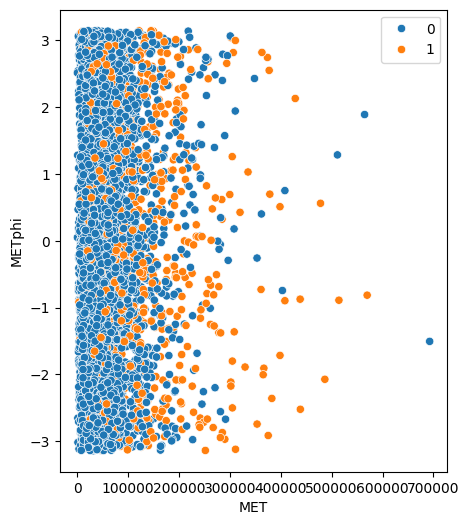

In [68]:
import seaborn as sns
fig = plt.figure(figsize=(5,6))
sns.scatterplot(x = features["MET"], y = features["METphi"], hue = target)

1. Probando con varias combinaciones de plots, no logré encontrar uno en que haya una separacion clara, por lo que no puedo asegurar que un modelo lineal haga una separacion eficiente. Pero si debería ser posible separar esta muestra en dos categorias con algun margen de error.

2. Si nuestro modelo lineal tiene una accuracy cercana al clasificador mayoritario significaria que el modelo no es muy bueno. Al tener una muestra desbalanceada, es mas probable que sea ttbar, por lo que si nuestro modelo iguala la accuracy de un modelo que dice que todas las colisiones son ttbar, entonces este estará mal.

3. En este caso accuracy no es una buena métrica, porque como vimos, con una clasificación aleatoria, se otbuvo una accuracy de 84%. La métrica mas adecuada es el Recall. Ya que este nos ayudaria a entender de la cantidad total de 4top, cuantos se lograron detectar. Y no se vería afectado por la distribución de la muetra.

In [30]:
bmodel = LinearSVC(dual = False, C=1000)
# Para modelo lineal, se prefiere dual=False cuando  n_samples > n_features.
#( el primal trabaja con las features, el dual trabaja con los alpha_i que estan asociados al numero de muestras)
# Si no, no va a converger!


**Qué signifca la elección de C grande?**

Un C grande significa que hay menos margen de error permitido. 

In [70]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=101)

In [71]:
l_benchmark_lim = cross_validate(bmodel, features_lim, target, cv = cv, scoring = 'accuracy', return_train_score=True)


In [33]:
l_benchmark_lim

{'fit_time': array([0.00612187, 0.01278496, 0.00453091, 0.0040679 , 0.00495434]),
 'score_time': array([0.0123589 , 0.0013001 , 0.00068498, 0.00055194, 0.00106287]),
 'test_score': array([0.841, 0.825, 0.829, 0.83 , 0.833]),
 'train_score': array([0.8315 , 0.83275, 0.8315 , 0.83125, 0.832  ])}

In [34]:
np.round(l_benchmark_lim['test_score'].mean(),3), np.round(l_benchmark_lim['test_score'].std(), 3)

(0.832, 0.005)

El promedio de accuracy para este caso parece alto, pero es igual de alto que el lazy classifier.
Podemos chequear las etiquetas con `cross_val_predict`, que compila las etiquetas predichas cuando cada objeto estaba en el fold test

In [35]:
ypred_bench_lim = cross_val_predict(bmodel, features_lim, target, cv = cv)

In [36]:
ypred_bench_lim

array([0, 0, 0, ..., 0, 0, 0])

### Pregunta: Qué podríamos haber hecho antes de haber construído el modelo SVM?

<details>
<summary>Mostrar explicación</summary>

### Escalar!

Los SVM son sensibles a la escala de las variables porque trabajan en el espacio de características.
La optimización  depende de productos punto entre pares de ejemplos:

$$
\mathbf{x}_i \cdot \mathbf{x}_j
$$

Por eso escalamos las features antes de entrenar un SVM. Una opción común es usar `StandardScaler`, que transforma cada feature para que tenga media 0 y desviación estándar 1.



</details>


In [37]:
from sklearn.pipeline import make_pipeline #Podemos construir varios pasos al mismo tiempo

¿Por qué usamos Pipeline?

Porque en validación cruzada, el escalamiento debe aprenderse usando solo los datos de entrenamiento de cada fold.  
Si escalamos todo el dataset antes de hacer CV, estaríamos usando información del conjunto de prueba para transformar los datos.  
Eso sería una forma sutil de data leakage.

[`make_pipeline`](https://scikit-learn.org/stable/modules/generated/sklearn.pipeline.make_pipeline.html)  permite encadenar varios pasos de preprocesamiento y modelado en un solo objeto.


In [38]:
piped_model = make_pipeline(StandardScaler(), LinearSVC(dual = False, C = 1000))
#modelo benchmark (de referencia)
benchmark_lim_piped = cross_validate(piped_model, features_lim, target, cv = cv, scoring = 'accuracy', return_train_score=True)

In [39]:
benchmark_lim_piped

{'fit_time': array([0.00697112, 0.01191497, 0.00553203, 0.00538683, 0.00475121]),
 'score_time': array([0.0127728 , 0.00141835, 0.00555611, 0.00307894, 0.0042789 ]),
 'test_score': array([0.894, 0.889, 0.89 , 0.892, 0.899]),
 'train_score': array([0.89575, 0.895  , 0.895  , 0.89825, 0.89275])}

In [40]:
np.round(benchmark_lim_piped['test_score'].mean(),3), np.round(benchmark_lim_piped['test_score'].std(), 3)

(0.893, 0.004)

In [41]:
np.round(benchmark_lim_piped['train_score'].mean(),3), np.round(benchmark_lim_piped['train_score'].std(), 3)

(0.895, 0.002)

Esto es una mejora!


Ahora necesitamos **diagnosticar** nuestro modelo:

Si comparamos el score para prueba y entrenamiento, notamos que hay un problema....
Miremos la curva de aprendizaje, que nos ayudará a mirar esto mejor y nos indicará si necesitamos más datos

### Curva de aprendizaje

In [42]:
from sklearn.model_selection import learning_curve

def plot_learning_curve(estimator, title, X, y, ylim=None, cv=5,
                        n_jobs=-1, train_sizes=np.linspace(.1, 1.0, 5), scoring = 'accuracy', scale = False):
    """
    Generate a simple plot of the test and training learning curve.

    Parameters
    ----------
    estimator : object type that implements the "fit" and "predict" methods
        An object of that type which is cloned for each validation.

    title : string
        Title for the chart.

    X : array-like, shape (n_samples, n_features)
        Training vector, where n_samples is the number of samples and
        n_features is the number of features.

    y : array-like, shape (n_samples) or (n_samples, n_features), optional
        Target relative to X for classification or regression;
        None for unsupervised learning.

    ylim : tuple, shape (ymin, ymax), optional
        Defines minimum and maximum yvalues plotted.

    cv : int, cross-validation generator or an iterable, optional
        Determines the cross-validation splitting strategy.
        Possible inputs for cv are:
          - None, to use the default 3-fold cross-validation,
          - integer, to specify the number of folds.
          - :term:`CV splitter`,
          - An iterable yielding (train, test) splits as arrays of indices.

        For integer/None inputs, if ``y`` is binary or multiclass,
        :class:`StratifiedKFold` used. If the estimator is not a classifier
        or if ``y`` is neither binary nor multiclass, :class:`KFold` is used.

        Refer :ref:`User Guide <cross_validation>` for the various
        cross-validators that can be used here.

    n_jobs : int or None, optional (default=None)
        Number of jobs to run in parallel.
        ``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.
        ``-1`` means using all processors. See :term:`Glossary <n_jobs>`
        for more details.

    train_sizes : array-like, shape (n_ticks,), dtype float or int
        Relative or absolute numbers of training examples that will be used to
        generate the learning curve. If the dtype is float, it is regarded as a
        fraction of the maximum size of the training set (that is determined
        by the selected validation method), i.e. it has to be within (0, 1].
        Otherwise it is interpreted as absolute sizes of the training sets.
        Note that for classification the number of samples usually have to
        be big enough to contain at least one sample from each class.
        (default: np.linspace(0.1, 1.0, 5))
    """
    plt.figure()
    plt.title(title)
    if ylim is not None:
        plt.ylim(*ylim)
    plt.xlabel("# of training examples",fontsize = 14)

    plt.ylabel("Accuracy score",fontsize = 14)

    if (scale == True):
        scaler = sklearn.preprocessing.StandardScaler()
        X = scaler.fit_transform(X)

    train_sizes, train_scores, test_scores = learning_curve(
        estimator, X, y, cv=cv, n_jobs=n_jobs, train_sizes=train_sizes, scoring = scoring)
    train_scores_mean = np.mean(train_scores, axis=1)
    train_scores_std = np.std(train_scores, axis=1)
    test_scores_mean = np.mean(test_scores, axis=1)
    test_scores_std = np.std(test_scores, axis=1)
#    plt.grid()

    plt.fill_between(train_sizes, train_scores_mean - train_scores_std,
                     train_scores_mean + train_scores_std, alpha=0.1,
                     color="b")
    plt.fill_between(train_sizes, test_scores_mean - test_scores_std,
                     test_scores_mean + test_scores_std, alpha=0.1, color="g")
    plt.plot(train_sizes, train_scores_mean, 'o-', color="b",
             label="Training score from CV")
    plt.plot(train_sizes, test_scores_mean, 'o-', color="g",
             label="Test score from CV")

    plt.legend(loc="best",fontsize = 12)
    return plt

In [43]:
cv

StratifiedKFold(n_splits=5, random_state=101, shuffle=True)

<module 'matplotlib.pyplot' from '/Users/bastianparedes/ML/lib/python3.9/site-packages/matplotlib/pyplot.py'>

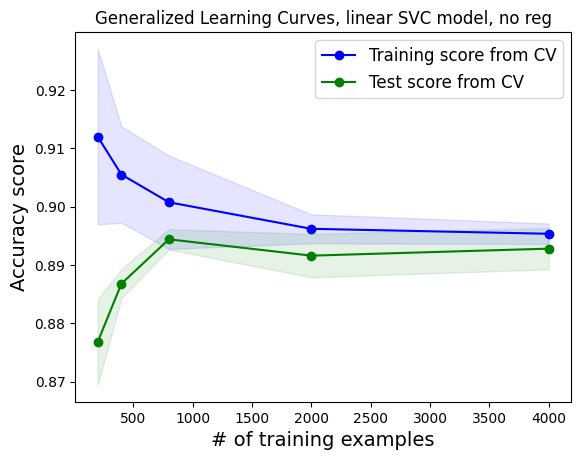

In [44]:
plot_learning_curve(piped_model, 'Generalized Learning Curves, linear SVC model, no reg',
                    features_lim, target, train_sizes = np.array([0.05,0.1,0.2,0.5,1.0]), cv = cv)

In [45]:
# Obtener predicciones usando validación cruzada
ypred_linear = cross_val_predict(
    piped_model,
    features_lim,
    target,
    cv=cv
)

#### Genere una matriz de confusión para esre modelo y evalúe el desempeño del modelo a partir del resultado.

también puede usar la función [`classification_report`](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.classification_report.html) de `sklearn`

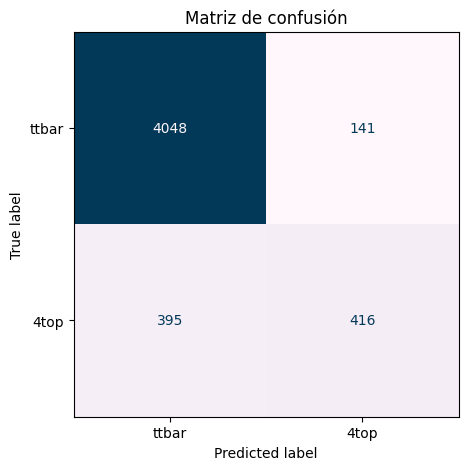

In [76]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
cm = confusion_matrix(target, ypred_linear)

fig, ax = plt.subplots(figsize=(5,5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["ttbar", "4top"])
disp.plot(cmap="PuBu", ax=ax, colorbar=False)

plt.title("Matriz de confusión")
plt.show()

In [77]:
print(metrics.classification_report(target, ypred_linear, target_names=["ttbar", "4top"]))

              precision    recall  f1-score   support

       ttbar       0.91      0.97      0.94      4189
        4top       0.75      0.51      0.61       811

    accuracy                           0.89      5000
   macro avg       0.83      0.74      0.77      5000
weighted avg       0.88      0.89      0.88      5000



## Conclusiones del benchmark lineal

1. En la curva de aprendizaje, ¿los scores de entrenamiento y validación son altos o bajos?  
   ¿Están separados o son parecidos?

2. ¿La curva sugiere alto bias o alta variance?  
   Justifique usando la relación entre score de entrenamiento y validación.

3. Considerando que usamos \(C=1000\), ¿qué nos dice este resultado sobre la capacidad del modelo lineal?

4. En la matriz de confusión, ¿el modelo detecta bien los eventos `4top` o tiende a clasificarlos como `ttbar`?

5. ¿qué métrica muestra mejor el problema con la clase minoritaria: accuracy, precision, recall o F1-score?

6. ¿El modelo lineal supera realmente los benchmarks ingenuos, o su buen desempeño se explica principalmente por el desbalance de clases?

7. ¿Qué evidencia nos indica que necesitamos un modelo más flexible que una frontera lineal?

In [78]:
from sklearn.dummy import DummyClassifier

for strat in ["most_frequent", "stratified"]:
    dummy = DummyClassifier(strategy=strat, random_state=0)
    ypred_dummy = cross_val_predict(dummy, features_lim, target, cv=cv)
    print(strat)
    print(metrics.classification_report(target, ypred_dummy, target_names=["ttbar", "4top"], zero_division=0))

most_frequent
              precision    recall  f1-score   support

       ttbar       0.84      1.00      0.91      4189
        4top       0.00      0.00      0.00       811

    accuracy                           0.84      5000
   macro avg       0.42      0.50      0.46      5000
weighted avg       0.70      0.84      0.76      5000

stratified
              precision    recall  f1-score   support

       ttbar       0.84      0.83      0.83      4189
        4top       0.17      0.19      0.18       811

    accuracy                           0.72      5000
   macro avg       0.51      0.51      0.51      5000
weighted avg       0.73      0.72      0.73      5000



1. En la curva de aprendizaje, el score de entrenamiento es muy alto para cantidades de datos mas bajas. A medida que aumentan, el score baja. Para la validación es lo contrario. A baja cantidad de datos, es mas bajo y sube con la cantidad de datos. Para altas cantidades de datos, estos scores son muy parecidos.

2. Esta distribucion sugiere una alto bias ya que el score entre el entrenamiento y la validacion es parecido a partir de 1000 numero de ejemplos o que indica que no hay un sobreajuste. Ademas el accuracy socre no es tan alto como se esperaria si fuera un sobreajuste.

3. Un C=1000 es muy alto. Es decir que castiga mucho el error de clasificación. Como aun asi el modelo esta bajo 0.9 en entrenamiento, esto nos dice que hay un problema sobre la capacidad del modelo lineal y no sobre los parametros y la regularización.

4. Se puede observar que de 811 4top, el modelo clasifica correctamente 416. Es apenas un poco mas de la mitad. ttbar se clasifica correctamente casi en su mayoria. Esto es porque el modelo esta sesgado por la cantidad de datos y su distribucion. Tiende a clasificar como ttbar. 

5. La metric que mejor muestra el problema es recall. Ya que para 4top es de 0.51. El resto de metricas se ve mas afectado por el sesgo y tienen valores mas altos.

6. se puede ver que el modelo lineal si supera los benchmarks. Aunque, debido al desbalance de clases, el clasificador lazy tiene una precision de 0.84 con el ttbar. Pero si vemos para 4top se puede ver que todas las metricas son de 0. Algo parecido con la clasificacion aleatoria. Pero nuestro modelo lineal tiene un recall de 0.51 para 4top, lo que indica que es mejor

7. La principal evidencia es el bias del modelo. Vimos que ni en los datos de entrenamiento el modelo convergio a 0.9 por lo que el modelo no logra ajustar mejor ni siquiera los datos de entrenamiento. Además se tiene un C = 1000, por lo que practiamente no hay regularización. Aqui el problema es la frontera y no el modelo como tal. Por ultimo, se vio gracias al recall de 4top, que esta frontera deja pasar a casi la mitad de estos. 

## Optimización de hiperparámetros

[`GridSearchCV`](https://scikit-learn.org/stable/modules/grid_search.html)selecciona los hiperparámetros que obtienen el mejor desempeño promedio en validación cruzada. Sin embargo, ese score puede ser optimista, porque los mismos folds de validación se usaron para elegir la mejor combinación de hiperparámetros.
Para estimar mejor el desempeño esperado en datos nuevos, se puede usar **validación cruzada anidada**. En este procedimiento, una validación cruzada interna selecciona los hiperparámetros, mientras que una validación cruzada externa evalúa el modelo seleccionado.
La idea central es no usar la misma información para elegir el modelo y para reportar su desempeño final.

La validación cruzada anidada es más rigurosa, pero no siempre vale la pena implementarla. Puede ser muy costosa, porque requiere repetir la búsqueda de hiperparámetros dentro de cada fold externo.En este notebook usaremos `GridSearchCV` para seleccionar hiperparámetros y comparar modelos, pero debemos recordar que el mejor score obtenido puede ser algo optimista. Si el objetivo fuera reportar un resultado final de investigación de manera rigurosa, sería mejor usar un conjunto de prueba independiente o validación cruzada anidada.

In [79]:
#ahora usamos la version general SVC y no la lineal, para cambiar el kernel
piped_model = make_pipeline(StandardScaler(), SVC())

piped_model.get_params() # esto nos muestra los parámetros para el scaler y el clasificador

{'memory': None,
 'steps': [('standardscaler', StandardScaler()), ('svc', SVC())],
 'transform_input': None,
 'verbose': False,
 'standardscaler': StandardScaler(),
 'svc': SVC(),
 'standardscaler__copy': True,
 'standardscaler__with_mean': True,
 'standardscaler__with_std': True,
 'svc__C': 1.0,
 'svc__break_ties': False,
 'svc__cache_size': 200,
 'svc__class_weight': None,
 'svc__coef0': 0.0,
 'svc__decision_function_shape': 'ovr',
 'svc__degree': 3,
 'svc__gamma': 'scale',
 'svc__kernel': 'rbf',
 'svc__max_iter': -1,
 'svc__probability': False,
 'svc__random_state': None,
 'svc__shrinking': True,
 'svc__tol': 0.001,
 'svc__verbose': False}

### Podemos definir un diccionario de valores parámetros para correr la optimización

Note que esto tomará tiempo (~3 min en mi computador)

Una vez que corramos esta celda, el objeto modelo tendra atributos de "best_score_", "best_params_" y "best_estimator_", que nos da acceso al estimador óptimo y "cv_results_" que pueden ser utilizados para visualizar la performance de todos los modelo

In [47]:
%%time
#optimizando SVC, TODAVIA NO ES CV ANIDADA!

#Probamos kernel polinomial y gaussiano, parámetros gamma y degree,
# además del parámetro de regularización
parameters = {'svc__kernel':['poly', 'rbf'], \
              'svc__gamma':[0.00001,'scale', 0.01, 0.1], 'svc__C':[0.1, 1.0, 10.0, 100.0, 1000], \
              'svc__degree': [2, 4, 8]}

# CV para todos los valores de los parámetros del GridSearch
model = GridSearchCV(piped_model, parameters, cv = StratifiedKFold(n_splits=5, shuffle=True), \
                     verbose = 2, n_jobs = 4, return_train_score=True)
model.fit(features_lim,target)

print('Best params, best score:', "{:.4f}".format(model.best_score_), \
      model.best_params_)

Fitting 5 folds for each of 120 candidates, totalling 600 fits
[CV] END svc__C=0.1, svc__degree=2, svc__gamma=1e-05, svc__kernel=poly; total time=   0.1s
[CV] END svc__C=0.1, svc__degree=2, svc__gamma=1e-05, svc__kernel=poly; total time=   0.1s
[CV] END svc__C=0.1, svc__degree=2, svc__gamma=1e-05, svc__kernel=poly; total time=   0.1s
[CV] END svc__C=0.1, svc__degree=2, svc__gamma=1e-05, svc__kernel=poly; total time=   0.1s
[CV] END svc__C=0.1, svc__degree=2, svc__gamma=1e-05, svc__kernel=poly; total time=   0.1s
[CV] END svc__C=0.1, svc__degree=2, svc__gamma=1e-05, svc__kernel=rbf; total time=   0.1s
[CV] END svc__C=0.1, svc__degree=2, svc__gamma=1e-05, svc__kernel=rbf; total time=   0.1s
[CV] END svc__C=0.1, svc__degree=2, svc__gamma=1e-05, svc__kernel=rbf; total time=   0.1s
[CV] END svc__C=0.1, svc__degree=2, svc__gamma=1e-05, svc__kernel=rbf; total time=   0.1s
[CV] END svc__C=0.1, svc__degree=2, svc__gamma=scale, svc__kernel=poly; total time=   0.1s
[CV] END svc__C=0.1, svc__degre

####  Ahora, visualizamos los modelos en un dataframe, y los rankeamos de acuerdo a los scores de prueba.

Miraremos el promedio y desviación estándar de los test scores, el promedio de los train scores, para evaluar si son distintos  y la significancia del resultado, y fitting time, para elegir el modelo más rápido en vez del mejor modelo, si es que los scores son comparables

In [48]:
scores_lim = pd.DataFrame(model.cv_results_)

scores_lim.columns

Index(['mean_fit_time', 'std_fit_time', 'mean_score_time', 'std_score_time',
       'param_svc__C', 'param_svc__degree', 'param_svc__gamma',
       'param_svc__kernel', 'params', 'split0_test_score', 'split1_test_score',
       'split2_test_score', 'split3_test_score', 'split4_test_score',
       'mean_test_score', 'std_test_score', 'rank_test_score',
       'split0_train_score', 'split1_train_score', 'split2_train_score',
       'split3_train_score', 'split4_train_score', 'mean_train_score',
       'std_train_score'],
      dtype='object')

In [49]:
scores_lim[['params','mean_test_score','std_test_score','mean_train_score', \
            'mean_fit_time']].sort_values(by = 'mean_test_score', ascending = False)

,params,mean_test_score,std_test_score,mean_train_score,mean_fit_time
69,"{'svc__C': 10.0, 'svc__degree': 8, 'svc__gamma': 0.01, 'svc__kernel': 'rbf'}",0.8980,0.003406,0.91195,0.077154
61,"{'svc__C': 10.0, 'svc__degree': 4, 'svc__gamma': 0.01, 'svc__kernel': 'rbf'}",0.8980,0.003406,0.91195,0.078139
53,"{'svc__C': 10.0, 'svc__degree': 2, 'svc__gamma': 0.01, 'svc__kernel': 'rbf'}",0.8980,0.003406,0.91195,0.078028
45,"{'svc__C': 1.0, 'svc__degree': 8, 'svc__gamma': 0.01, 'svc__kernel': 'rbf'}",0.8962,0.003868,0.90055,0.066722
29,"{'svc__C': 1.0, 'svc__degree': 2, 'svc__gamma': 0.01, 'svc__kernel': 'rbf'}",0.8962,0.003868,0.90055,0.065613
37,"{'svc__C': 1.0, 'svc__degree': 4, 'svc__gamma': 0.01, 'svc__kernel': 'rbf'}",0.8962,0.003868,0.90055,0.066497
43,"{'svc__C': 1.0, 'svc__degree': 8, 'svc__gamma': 'scale', 'svc__kernel': 'rbf'}",0.8960,0.006356,0.92160,0.082192
35,"{'svc__C': 1.0, 'svc__degree': 4, 'svc__gamma': 'scale', 'svc__kernel': 'rbf'}",0.8960,0.006356,0.92160,0.081424
27,"{'svc__C': 1.0, 'svc__degree': 2, 'svc__gamma': 'scale', 'svc__kernel': 'rbf'}",0.8960,0.006356,0.92160,0.078029
47,"{'svc__C': 1.0, 'svc__degree': 8, 'svc__gamma': 0.1, 'svc__kernel': 'rbf'}",0.8922,0.003429,0.93925,0.096257


Observamos que el kernel rbf es preferido constantemente, los valores de $C$ y $\gamma$ no afectan demasiado los scores. GridSearch es insensible a combinaciones de parámetros irrelevantes, por ejemplo, los tres primeros modelos son idénticos porque el grado del kernel polinomial no afecta al kernel rbf.

#### Podemos aislar un solo tipo de kernel

In [50]:
scores_lim[scores_lim['param_svc__kernel'] == 'poly'][['params','mean_test_score','std_test_score',\
                        'mean_train_score','mean_fit_time']].sort_values(by = 'mean_test_score', ascending = False)

,params,mean_test_score,std_test_score,mean_train_score,mean_fit_time
76,"{'svc__C': 100.0, 'svc__degree': 2, 'svc__gamma': 0.01, 'svc__kernel': 'poly'}",0.8764,0.005886,0.88440,0.121558
30,"{'svc__C': 1.0, 'svc__degree': 2, 'svc__gamma': 0.1, 'svc__kernel': 'poly'}",0.8764,0.005886,0.88435,0.121451
74,"{'svc__C': 100.0, 'svc__degree': 2, 'svc__gamma': 'scale', 'svc__kernel': 'poly'}",0.8764,0.006280,0.88850,1.570563
50,"{'svc__C': 10.0, 'svc__degree': 2, 'svc__gamma': 'scale', 'svc__kernel': 'poly'}",0.8760,0.005831,0.88735,0.213009
100,"{'svc__C': 1000, 'svc__degree': 2, 'svc__gamma': 0.01, 'svc__kernel': 'poly'}",0.8760,0.006899,0.88810,0.537000
54,"{'svc__C': 10.0, 'svc__degree': 2, 'svc__gamma': 0.1, 'svc__kernel': 'poly'}",0.8760,0.006899,0.88810,0.538764
78,"{'svc__C': 100.0, 'svc__degree': 2, 'svc__gamma': 0.1, 'svc__kernel': 'poly'}",0.8756,0.006086,0.88885,4.982782
98,"{'svc__C': 1000, 'svc__degree': 2, 'svc__gamma': 'scale', 'svc__kernel': 'poly'}",0.8756,0.005851,0.88885,14.916366
102,"{'svc__C': 1000, 'svc__degree': 2, 'svc__gamma': 0.1, 'svc__kernel': 'poly'}",0.8754,0.005607,0.88890,50.591106
26,"{'svc__C': 1.0, 'svc__degree': 2, 'svc__gamma': 'scale', 'svc__kernel': 'poly'}",0.8746,0.006344,0.88215,0.093741


In [51]:
best_model = model.best_estimator_

ypred_best = cross_val_predict(
    best_model,
    features_lim,
    target,
    cv=cv
)

**Construya la matriz de confusión para el modelo optimizado**

Preguntas:

- ¿Cuál es la accuracy del modelo optimizado? ---> 0.9
- ¿Cuál es la precision para la clase 4top? ---> 0.74
- ¿Cuál es el recall para la clase 4top? ---> 0.55 
- ¿Cuál es el F1-score para la clase 4top? ---> 0.63
- ¿Qué métrica mejoró más respecto al benchmark lineal? ---> el recall mejoro de 0.51 a 0.55 
- ¿Qué métrica empeoró o cambió muy poco? ---> la presición casi no cambio (bajo de 0.01) 
- ¿La mejora en accuracy refleja una mejora real para la clase 4top? ---> La accuracy sigue dominada por los ttbar, por lo que no hay una mejora significativa. El recall es el que mejoró 
- ¿El modelo optimizado detecta mejor la clase minoritaria que el benchmark lineal? ---> La deteca mejor, pero no mucho mejor. 

Complete la tabla de comparación


| Modelo            | Accuracy | Precision `4top` | Recall `4top` | F1-score `4top` | Comentario |
| ----------------- | -------: | ---------------: | ------------: | --------------: | ---------- |
| Benchmark lineal  |   0.89   |       0.75       |     0.51      |      0.61       |            |
| Modelo optimizado |   0.90   |       0.74       |     0.55      |      0.63       |            |

- ¿El modelo optimizado mejora todas las métricas o solo algunas? ---> Solo mejoran el recall, el F1 y un poco el accuracy. La precision se mantiene (hasta disminuye un poco)
- Si una métrica mejora pero otra empeora, ¿cómo decidiría cuál modelo es mejor? ---> Depende de lo que se busque. Como buscamos 4top nos interesa recall ya que este sobrevive mejor al sesgo. 
- ¿La mejora justifica usar un modelo más complejo? ---> Si, por mas pequeña que sea la mejora, se tiene un resultado mejor. 


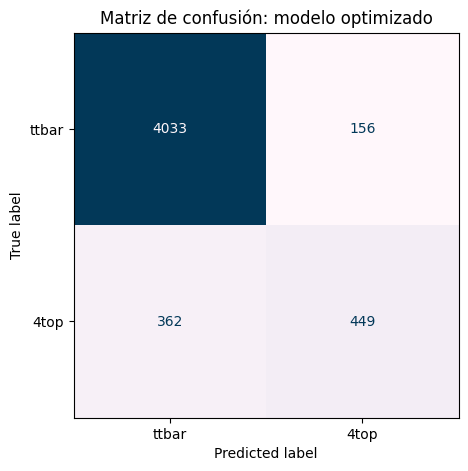

In [83]:
cm_best = confusion_matrix(target, ypred_best)

fig, ax = plt.subplots(figsize=(5,5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_best, display_labels=["ttbar", "4top"])
disp.plot(cmap="PuBu", ax=ax, colorbar=False)
plt.title("Matriz de confusión: modelo optimizado")
plt.show()


In [85]:
print(model.best_params_)
print(metrics.classification_report(target, ypred_best, target_names=["ttbar", "4top"]))

{'svc__C': 10.0, 'svc__degree': 2, 'svc__gamma': 0.01, 'svc__kernel': 'rbf'}
              precision    recall  f1-score   support

       ttbar       0.92      0.96      0.94      4189
        4top       0.74      0.55      0.63       811

    accuracy                           0.90      5000
   macro avg       0.83      0.76      0.79      5000
weighted avg       0.89      0.90      0.89      5000



#### Diagnóstico final

- ¿Qué modelo elegiría para reportar y por qué?
- ¿Qué limitación importante todavía tiene el modelo?

1. Eligiria el modelo optimizado ya que, en este se caso se busca detectar 4top y este modelo lo hace mejor. Aumenta el recall de 0.51 a 0.55 y el F1 de 0.61 a 0.63, manteniendo prácticamente la misma precision (0.75 -> 0.74).  

2. La principal limitación es que el modelo sigue perdiendo cerca del 45% de los eventos 4top con un recall de 0.55. El modelo no lineal mejora poco, lo que sugiere que el problema no es solo la forma de la frontera sino que esta en los datos disponibles. Además, los hiperparámetros se eligieron optimizando accuracy, que favorece a la clase mayoritaria y no se trató el desbalance de clases.


## Actividad final: mejorar el modelo

Hasta ahora usamos un conjunto limitado de features para construir y optimizar nuestros modelos. Sin embargo, el desempeño de un modelo no depende solo del algoritmo o de los hiperparámetros: también depende de la información que le entregamos.

En este dataset, cada evento contiene información de varias partículas reconstruidas. Como los eventos `4top` suelen ser más complejos que los eventos `ttbar`, es razonable pensar que usar más información del evento podría ayudar al modelo a distinguir mejor ambas clases.

**Proponga una estrategia para mejorar el modelo explorando nuevas features o usando una representación más completa de los eventos.**

Puede considerar, por ejemplo:

- incluir información de más partículas;
- usar todas las partículas disponibles;
- construir variables derivadas;
- modificar el tratamiento de valores faltantes;
- comparar distintos subconjuntos de features;
- cambiar la métrica usada para optimizar el modelo.

Luego evalúe si su propuesta mejora el desempeño respecto al modelo anterior.

### Preguntas

1. ¿Qué cambio hizo?
4. ¿Mejoró la detección de eventos `4top`?
5. ¿Qué ocurrió con la matriz de confusión?
6. ¿La mejora justifica el aumento de complejidad?
7. ¿Qué aprendió sobre la importancia de las features en este problema?

In [91]:
from sklearn.metrics import confusion_matrix

def evaluar(nombre, estimador, X):
    ypred = cross_val_predict(estimador, X, target, cv=cv, n_jobs=4)
    print(nombre)
    print(confusion_matrix(target, ypred))
    return {
        "Accuracy": metrics.accuracy_score(target, ypred),
        "Precision 4top": metrics.precision_score(target, ypred),
        "Recall 4top": metrics.recall_score(target, ypred),
        "F1 4top": metrics.f1_score(target, ypred),
    }

In [92]:
types = features[type_cols]
E = features[[f"P{4*i-3}" for i in range(1, 14)]].to_numpy()
pt = features[[f"P{4*i-2}" for i in range(1, 14)]].to_numpy()

es_jet = types.isin(["j", "b"]).to_numpy()
lep_pos = ["e+", "m+"]
lep_neg = ["e-", "m-"]

derivadas = pd.DataFrame({
    "MET": features["MET"],
    "n_obj": types.notna().sum(axis=1),
    "n_j": (types == "j").sum(axis=1),
    "n_b": (types == "b").sum(axis=1),
    "n_lep": types.isin(lep_pos + lep_neg).sum(axis=1),
    "carga_lep": types.isin(lep_pos).sum(axis=1) - types.isin(lep_neg).sum(axis=1),
    "HT": np.where(es_jet, pt, 0).sum(axis=1),
    "sum_pt": np.nansum(pt, axis=1),
    "sum_E": np.nansum(E, axis=1),
}, index=features.index)

derivadas.groupby(target).mean().round(2)

,MET,n_obj,n_j,n_b,n_lep,carga_lep,HT,sum_pt,sum_E
0,54711.24,5.63,4.1,1.22,0.28,0.01,379689.77,396017.85,1174442.43
1,112416.76,9.40,6.5,2.42,0.44,-0.03,953068.87,989385.88,2277920.30


In [93]:
features_num_n = features.select_dtypes(include="number").fillna(0)
features_num_n["n_obj"] = derivadas["n_obj"]

features_combo = pd.concat([features_num_n, derivadas.drop(columns=["MET", "n_obj"])], axis=1)

svc_best = make_pipeline(StandardScaler(), SVC(kernel="rbf", C=10, gamma=0.01))
svc_bal = make_pipeline(StandardScaler(), SVC(kernel="rbf", C=10, gamma=0.01, class_weight="balanced"))

resultados = {
    "Optimizado (lim)": evaluar("Optimizado (lim)", svc_best, features_lim),
    "Todas numéricas + n_obj": evaluar("Todas numéricas + n_obj", svc_best, features_num_n),
    "Solo derivadas": evaluar("Solo derivadas", svc_best, derivadas),
    "Numéricas + derivadas": evaluar("Numéricas + derivadas", svc_best, features_combo),
    "Numéricas + derivadas (balanced)": evaluar("Numéricas + derivadas (balanced)", svc_bal, features_combo),
}

pd.DataFrame(resultados).T.round(3)

Optimizado (lim)
[[4033  156]
 [ 362  449]]
Todas numéricas + n_obj
[[4029  160]
 [ 197  614]]
Solo derivadas
[[4083  106]
 [ 164  647]]
Numéricas + derivadas
[[4052  137]
 [ 174  637]]
Numéricas + derivadas (balanced)
[[3998  191]
 [ 142  669]]


,Accuracy,Precision 4top,Recall 4top,F1 4top
Optimizado (lim),0.896,0.742,0.554,0.634
Todas numéricas + n_obj,0.929,0.793,0.757,0.775
Solo derivadas,0.946,0.859,0.798,0.827
Numéricas + derivadas,0.938,0.823,0.785,0.804
Numéricas + derivadas (balanced),0.933,0.778,0.825,0.801


1. Para este modelo se crearon nuevas variables. Si el modelo no entiende la fisica detras y solo esta clasificando segun unas cuantas columnas, es normal que no se ppueda clasificar bien cuando hay una desigualdad en los datos. Se añadieron las columna: número de objetos, número de jets, número de b-jets, número de leptones, carga leptónica total, HT (suma del pT de los jets), suma del pT y suma de la energía de todas las partículas, además de MET. Estas usan las 13 partículas e incorporan su tipo, información que el modelo anterior no tenía. Ademas se probaron y compararon varios conjuntos con distintos parametros. 

2. Si mejoro la deteccion de 4top. Ahora se puede ver un aumento de todas las metricas en todos los conjuntos. El de solo derivadas tiene un recall de 0.859, por lo que solo un 15% no fue detectado. Además el F1 subio de 0.63 a 0.83, mientras la precision también mejoro de 0.74 a 0.86.

3. Con solo variables derivadas, los falsos negativos bajan de 362 a 164 y los falsos positivos también bajan, de 156 a 106. Lo que es una mejora significativa respecto a los modelos anteriores. 

4. En este caso la complejidad no aumenta, sino que disminuye. El mejor modelo usa solo 9 variables, contra 18 del modelo anterior. Construir las variables requiere información física, pero el modelo es más simple, más rápido e interpretable.

5. Las features importan mucho más que el algoritmo en este problema. Optimizar hiperparámetros y cambiar a un kernel no lineal mejoró el F1 en ~0.03, mientras que cambiar las features lo mejoró en ~0.19. Además, pocas variables con sentido físico funcionan mejor que muchas variables crudas por partícula, donde el orden de las partículas es arbitrario y los faltantes se rellenan con ceros. Esto muestra que el alto bias del modelo original se debía principalmente a la falta de información relevante en las features, no solo a la forma de la frontera.
